# Tutorial #07 — Inception Model (InceptionV3)

**Atualizado para TensorFlow 2.x / Keras**

Baseado no tutorial original de Magnus Erik Hvass Pedersen, reescrito para funcionar com TF 2.x usando `tf.keras.applications.InceptionV3`.


## Introdução

Este tutorial demonstra como usar a Rede Neural Profunda pré-treinada chamada **InceptionV3** para classificação de imagens.

O modelo InceptionV3:
- Possui cerca de **25 milhões de parâmetros**
- É treinado no dataset **ImageNet** com **1.000 classes**
- Espera imagens de **299 × 299 pixels**
- É carregado diretamente via `tf.keras.applications` — sem necessidade de download manual


## Arquitetura Inception (Fluxo de Dados)

O InceptionV3 é uma CNN profunda com **módulos Inception** — blocos que aplicam convoluções de diferentes tamanhos (1×1, 3×3, 5×5) em paralelo e concatenam os resultados. Isso permite capturar features em múltiplas escalas simultaneamente.

**Camadas principais:**
1. Stem (Conv + BN + ReLU repetido)
2. Módulos Inception A, B, C
3. Camadas de redução de dimensionalidade
4. Global Average Pooling
5. Softmax → 1.000 classes (ImageNet)


## 1. Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image as keras_image
from IPython.display import display, Image
import os
import urllib.request
from PIL import Image as PILImage

print(f"TensorFlow versão: {tf.__version__}")
print(f"Keras versão: {tf.keras.__version__}")


TensorFlow versão: 2.20.0
Keras versão: 3.13.2


## 2. Carregar o Modelo InceptionV3

O modelo é baixado automaticamente pelo Keras (pesos pré-treinados no ImageNet, ~92 MB). Isso acontece apenas uma vez — o Keras faz cache dos pesos.


In [2]:
# Carrega InceptionV3 com pesos pré-treinados no ImageNet
model = InceptionV3(weights='imagenet')

print(f"Modelo carregado com sucesso!")
print(f"Entrada esperada: {model.input_shape}")
print(f"Saída (número de classes): {model.output_shape}")


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Modelo carregado com sucesso!
Entrada esperada: (None, 299, 299, 3)
Saída (número de classes): (None, 1000)


### Resumo da Arquitetura

Veja quantas camadas e parâmetros o InceptionV3 possui:


In [3]:
# Exibe um resumo compacto
total_params = model.count_params()
trainable = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"Total de parâmetros: {total_params:,}")
print(f"Parâmetros treináveis: {trainable:,}")
print(f"Número de camadas: {len(model.layers)}")


Total de parâmetros: 23,851,784
Parâmetros treináveis: 23,817,352
Número de camadas: 313


## 3. Funções Auxiliares

Definimos funções para:
1. **Pré-processar** a imagem para o formato esperado pelo InceptionV3
2. **Classificar** e exibir as previsões
3. **Visualizar** a imagem redimensionada (como o modelo a vê)


In [4]:
def load_and_preprocess(image_path, target_size=(299, 299)):
    """
    Carrega uma imagem, redimensiona para 299x299 e pré-processa
    para o InceptionV3 (valores entre -1 e 1).

    Retorna:
        img_array: array 4D (1, 299, 299, 3) pronto para inferência
        img_pil: imagem PIL original redimensionada
    """
    img_pil = PILImage.open(image_path).convert('RGB')
    img_pil_resized = img_pil.resize(target_size, PILImage.LANCZOS)
    img_array = keras_image.img_to_array(img_pil_resized)
    img_array = np.expand_dims(img_array, axis=0)  # (1, 299, 299, 3)
    img_array = preprocess_input(img_array)         # Normaliza para [-1, 1]
    return img_array, img_pil_resized


def classify(image_path, top_k=10):
    """
    Exibe a imagem e classifica usando InceptionV3.
    Mostra as top_k previsões com scores.
    """
    print(f"Classificando: {image_path}")

    # Exibe a imagem original
    display(Image(image_path))

    # Pré-processa e faz a inferência
    img_array, _ = load_and_preprocess(image_path)
    predictions = model.predict(img_array, verbose=0)

    # Decodifica as top-k previsões
    top_predictions = decode_predictions(predictions, top=top_k)[0]

    print(f"\nTop-{top_k} previsões:")
    print("-" * 45)
    for i, (imagenet_id, label, score) in enumerate(top_predictions, 1):
        print(f"{i:2d}. {score*100:6.2f}% : {label}")
    print()

    return top_predictions


def plot_resized_image(image_path):
    """
    Mostra como a imagem fica após o redimensionamento para 299x299
    (que é o que o modelo realmente vê).
    """
    _, img_resized = load_and_preprocess(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Original
    original = PILImage.open(image_path).convert('RGB')
    axes[0].imshow(original)
    axes[0].set_title(f"Original\n{original.size[0]}x{original.size[1]} px", fontsize=12)
    axes[0].axis('off')

    # Redimensionada
    axes[1].imshow(img_resized)
    axes[1].set_title("Como o modelo vê\n299x299 px", fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

print("Funções auxiliares definidas com sucesso!")


Funções auxiliares definidas com sucesso!


## 4. Preparar Imagens de Teste

Vamos baixar algumas imagens de exemplo para testar o modelo.

> **Nota:** Você também pode usar suas próprias imagens — basta colocá-las na pasta `images/` e chamar `classify("images/sua_imagem.jpg")`.


In [20]:
# Cria diretório de imagens
os.makedirs('images', exist_ok=True)

# Dicionário de imagens de exemplo para download
sample_images = {
    'images/panda.jpg': [
        'https://storage.googleapis.com/download.tensorflow.org/example_images/Giant_Panda_2.jpeg',
    ],
    'images/macaw.jpg': [
        'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01818515_macaw.JPEG',
    ],
    'images/elephant.jpg': [
        'https://upload.wikimedia.org/wikipedia/commons/thumb/3/37/African_Bush_Elephant.jpg/800px-African_Bush_Elephant.jpg',
        'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02504458_African_elephant.JPEG',
        'https://picsum.photos/seed/elephant/400/300',
    ],
    'images/cat.jpg': [
        'https://raw.githubusercontent.com/pytorch/hub/master/images/cat.jpg',
        'https://picsum.photos/seed/cat/400/300',
    ],
    'images/dog.jpg': [
        'https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg',
    ],
}

downloaded = []
failed = []

for filename, urls in sample_images.items():
    if os.path.exists(filename):
        print(f"  Já existe: {filename}")
        downloaded.append(filename)
        continue

    success = False
    for url in urls:
        try:
            urllib.request.urlretrieve(url, filename)
            print(f"✓ Baixado: {filename} ({url})")
            downloaded.append(filename)
            success = True
            break  # URL funcionou, passa para a próxima imagem
        except Exception as e:
            print(f"  ↳ Tentativa falhou ({url}): {e}")

    if not success:
        print(f"✗ Todas as URLs falharam: {filename}")
        failed.append(filename)

print(f"\nImagens disponíveis: {len(downloaded)}")
if failed:
    print(f"Falhas: {failed}")

  Já existe: images/panda.jpg
  Já existe: images/macaw.jpg
  Já existe: images/elephant.jpg
  Já existe: images/cat.jpg
  Já existe: images/dog.jpg

Imagens disponíveis: 5


## 5. Classificação: Panda

O InceptionV3 foi treinado no ImageNet que inclui a classe `giant_panda`. Vamos ver a confiança do modelo.


Classificando: images/panda.jpg


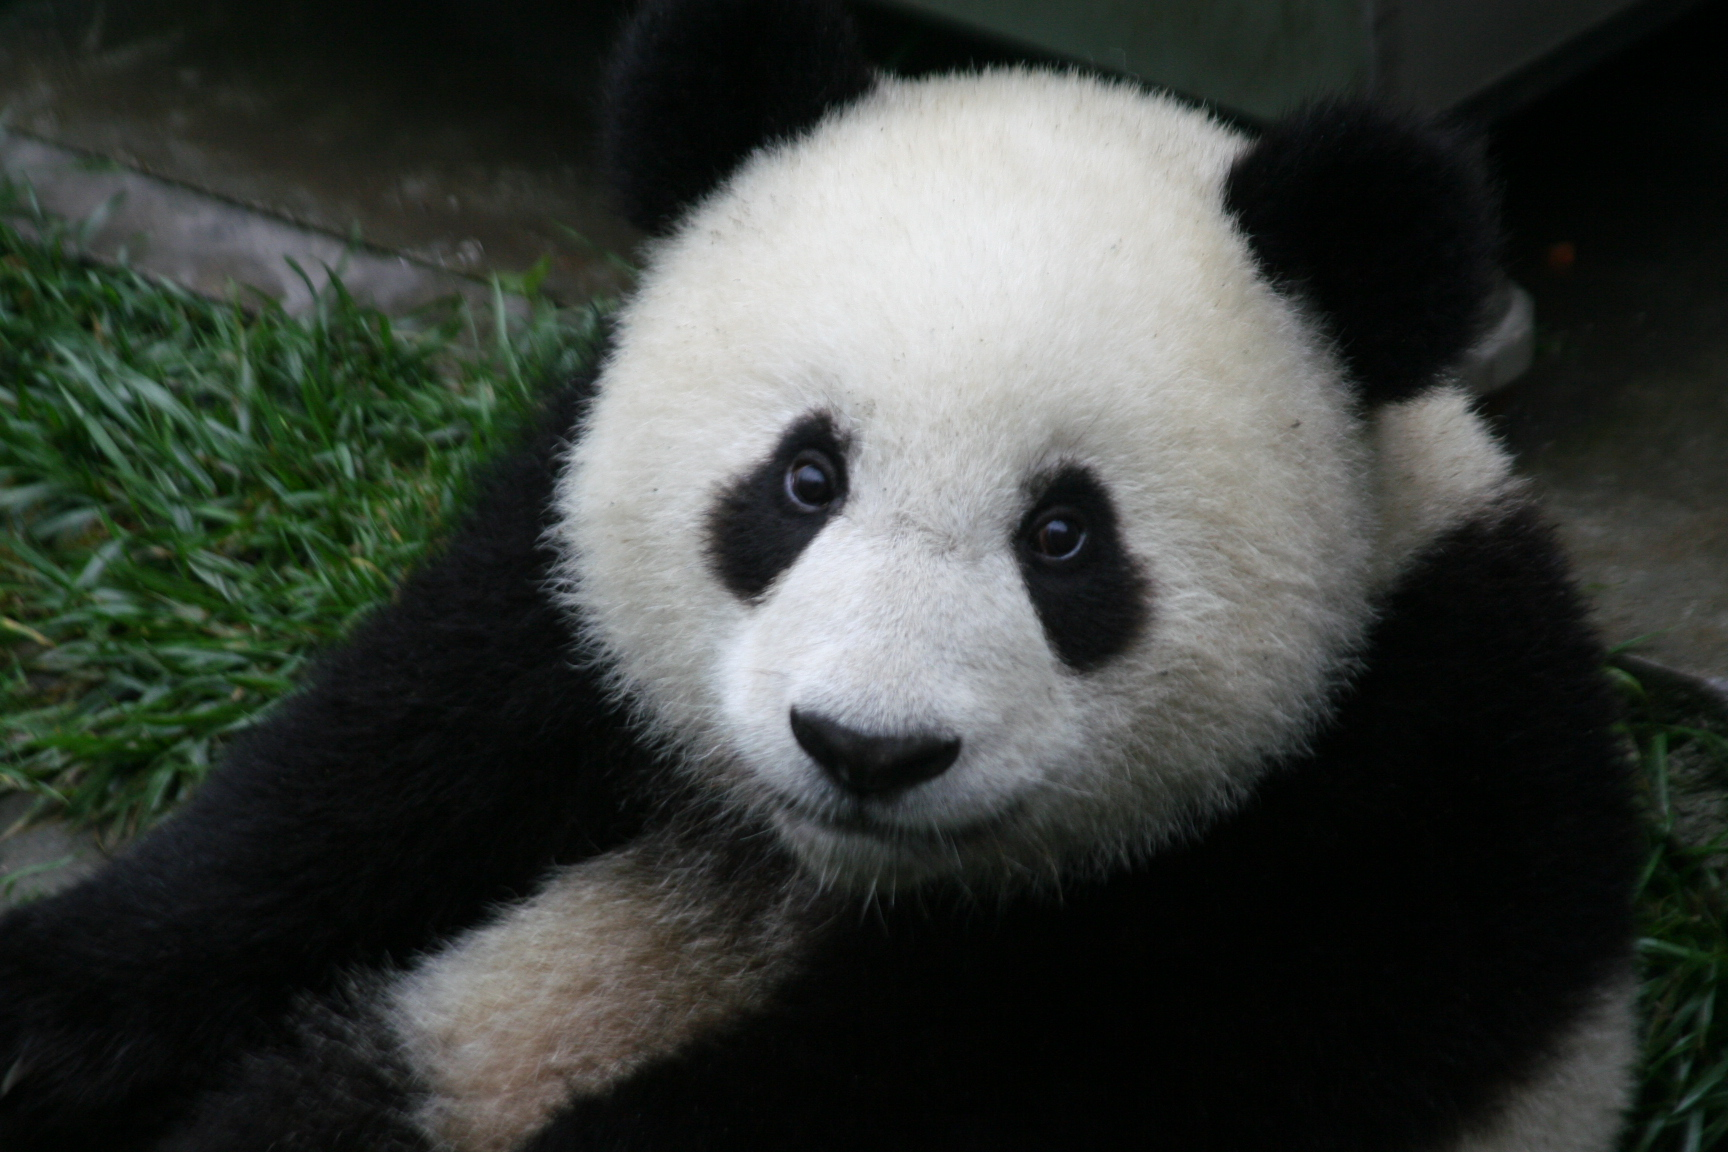

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Top-10 previsões:
---------------------------------------------
 1.  94.78% : giant_panda
 2.   0.10% : soccer_ball
 3.   0.07% : lesser_panda
 4.   0.04% : teddy
 5.   0.04% : space_shuttle
 6.   0.03% : earthstar
 7.   0.03% : knee_pad
 8.   0.03% : white_stork
 9.   0.03% : gorilla
10.   0.02% : indri



In [6]:
if os.path.exists('images/panda.jpg'):
    panda_preds = classify('images/panda.jpg', top_k=10)
else:
    print("Imagem não disponível. Faça upload de 'images/panda.jpg'")


## 6. Visualizar a Imagem Redimensionada

O InceptionV3 espera imagens de **299×299 pixels**. Se a imagem tem outra resolução, ela é redimensionada automaticamente. Isso pode distorcer a imagem se ela não for quadrada.

Compare a imagem original com a versão que o modelo realmente processa:


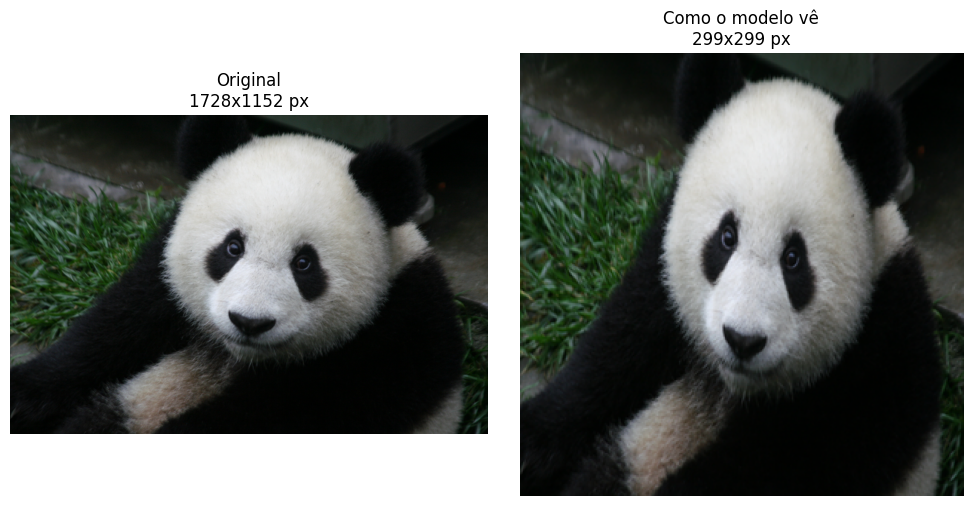

In [7]:
if os.path.exists('images/panda.jpg'):
    plot_resized_image('images/panda.jpg')


## 7. Classificação: Elefante


Classificando: images/elephant.jpg


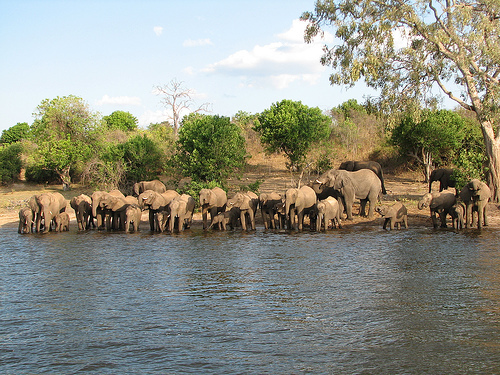


Top-10 previsões:
---------------------------------------------
 1.  96.09% : African_elephant
 2.   1.17% : tusker
 3.   0.88% : Indian_elephant
 4.   0.02% : mushroom
 5.   0.01% : medicine_chest
 6.   0.01% : zebra
 7.   0.01% : car_mirror
 8.   0.01% : king_penguin
 9.   0.01% : shower_curtain
10.   0.01% : radio_telescope



In [8]:
if os.path.exists('images/elephant.jpg'):
    classify('images/elephant.jpg', top_k=10)
else:
    print("Imagem não disponível.")


## 8. Classificação: Gato


In [9]:
if os.path.exists('images/cat.jpg'):
    classify('images/cat.jpg', top_k=10)
else:
    print("Imagem não disponível.")


Imagem não disponível.


## 9. Classificação: Cachorro


Classificando: images/dog.jpg


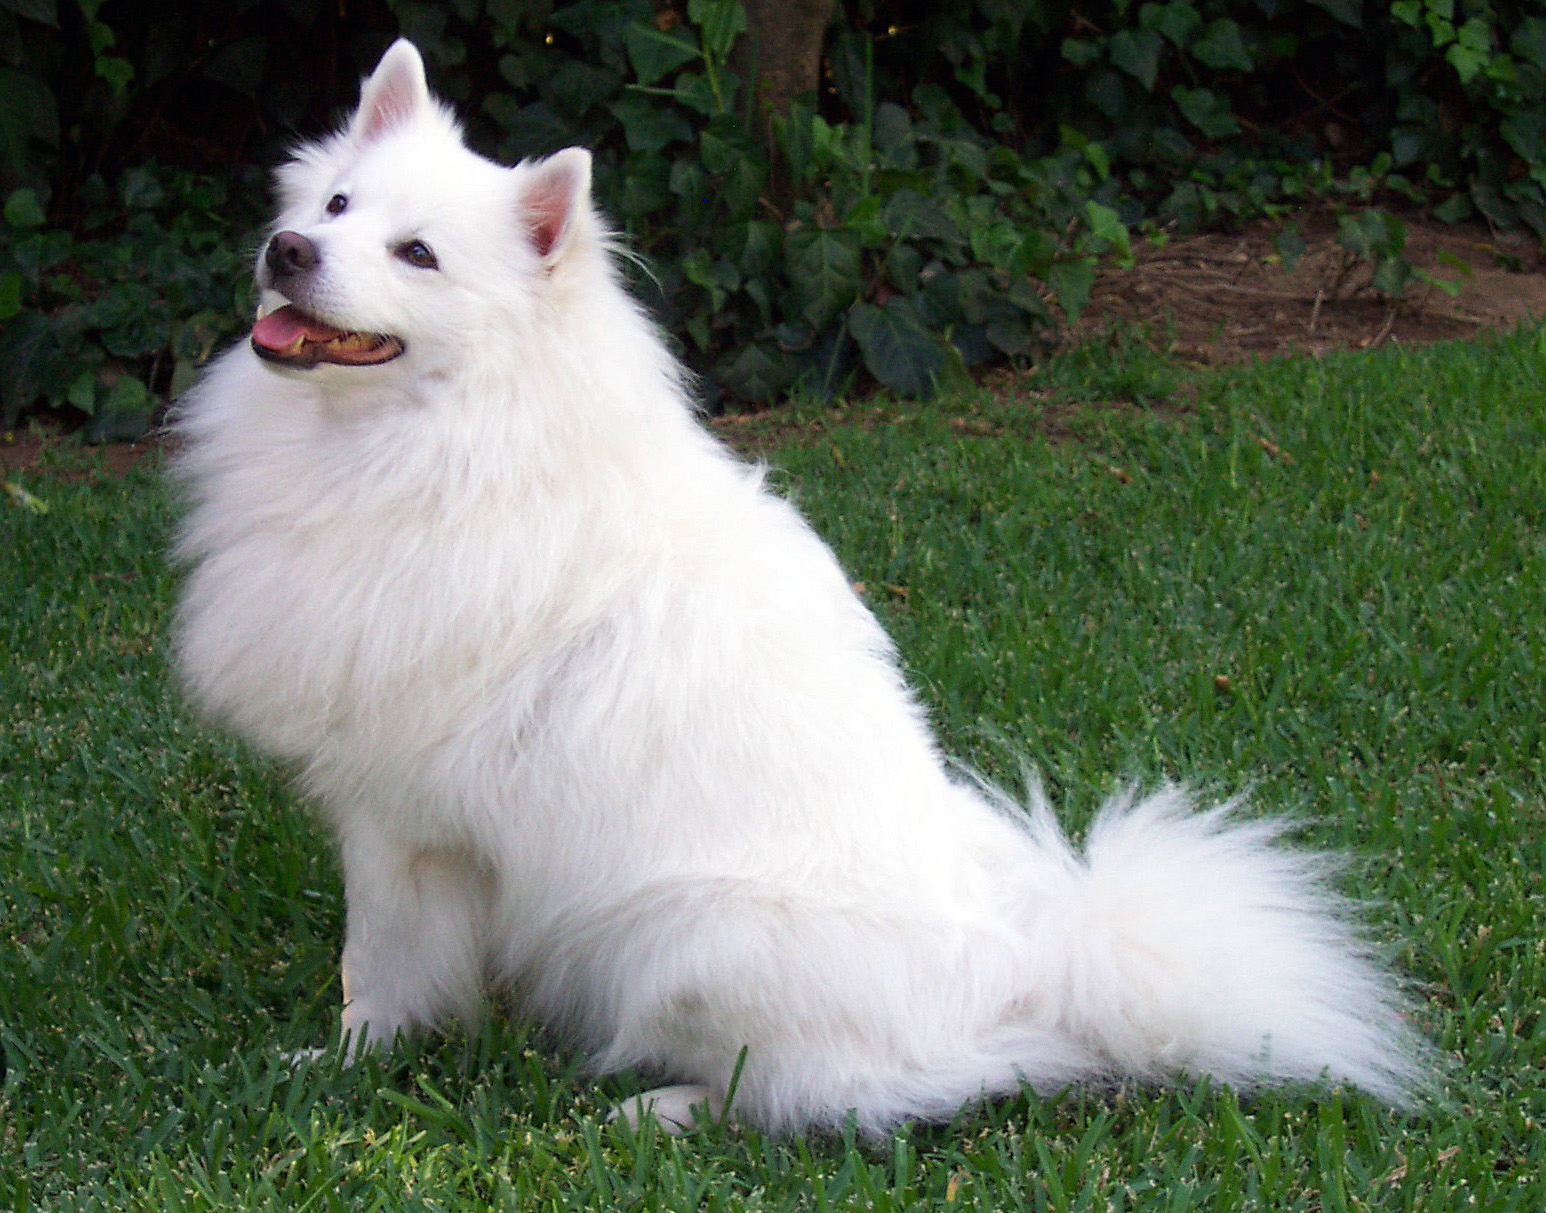


Top-10 previsões:
---------------------------------------------
 1.  87.99% : Samoyed
 2.   1.72% : Arctic_fox
 3.   0.90% : Pomeranian
 4.   0.82% : white_wolf
 5.   0.31% : keeshond
 6.   0.18% : Eskimo_dog
 7.   0.17% : Great_Pyrenees
 8.   0.08% : papillon
 9.   0.07% : kuvasz
10.   0.07% : Japanese_spaniel



In [10]:
if os.path.exists('images/dog.jpg'):
    classify('images/dog.jpg', top_k=10)
else:
    print("Imagem não disponível.")


## 10. Usar suas Próprias Imagens

Você pode classificar qualquer imagem local. Basta fornecer o caminho:


In [11]:
# Exemplo: substitua pelo caminho da sua imagem
# classify('caminho/para/sua_imagem.jpg', top_k=5)

# Ou use uma URL — baixe primeiro:
# url = 'https://exemplo.com/imagem.jpg'
# urllib.request.urlretrieve(url, 'images/minha_imagem.jpg')
# classify('images/minha_imagem.jpg')

print("Descomente e adapte o código acima para usar suas próprias imagens.")


Descomente e adapte o código acima para usar suas próprias imagens.


## 11. Interpretação dos Scores (Softmax)

A saída do InceptionV3 passa por uma função **Softmax**, que transforma os logits em probabilidades:
- Os valores estão entre **0 e 1**
- A **soma de todos os 1.000 valores é igual a 1**
- Um score alto (ex: 89%) indica alta confiança na previsão

Vamos visualizar a distribuição dos scores para uma imagem:


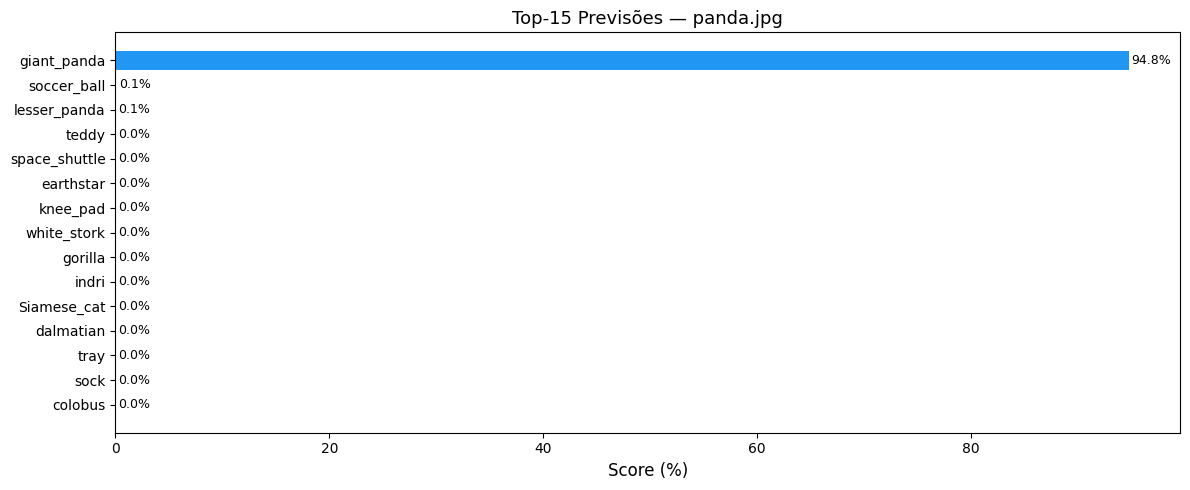


Soma de todos os 1000 scores: 1.000000 (deve ser ~1.0)
Score máximo: 94.78%
Score médio:  0.1000% (1000 classes → ~0.1% cada)


In [12]:
def plot_score_distribution(image_path, top_k=20):
    """
    Plota a distribuição dos top-k scores de classificação.
    """
    img_array, _ = load_and_preprocess(image_path)
    predictions = model.predict(img_array, verbose=0)[0]

    # Top-k índices
    top_indices = np.argsort(predictions)[::-1][:top_k]
    top_scores = predictions[top_indices]

    # Decodifica labels
    decoded = decode_predictions(predictions.reshape(1, -1), top=top_k)[0]
    labels = [d[1] for d in decoded]
    scores = [d[2] for d in decoded]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#2196F3' if i == 0 else '#90CAF9' for i in range(len(labels))]
    bars = ax.barh(range(len(labels)), [s * 100 for s in scores], color=colors)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Score (%)', fontsize=12)
    ax.set_title(f'Top-{top_k} Previsões — {os.path.basename(image_path)}', fontsize=13)

    # Adiciona valores nas barras
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{score*100:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\nSoma de todos os 1000 scores: {predictions.sum():.6f} (deve ser ~1.0)")
    print(f"Score máximo: {predictions.max()*100:.2f}%")
    print(f"Score médio:  {predictions.mean()*100:.4f}% (1000 classes → ~0.1% cada)")


# Plota para o panda (se disponível)
if os.path.exists('images/panda.jpg'):
    plot_score_distribution('images/panda.jpg', top_k=15)


## 12. Efeito do Tamanho da Imagem

Como o redimensionamento afeta a classificação? Vamos testar com a mesma imagem em diferentes tamanhos.

Criamos versões reduzidas artificialmente e verificamos se o modelo ainda classifica corretamente:


Testando diferentes resoluções — Panda:
  299x299 px → giant_panda               (94.8%)
  150x150 px → giant_panda               (91.7%)
  100x100 px → giant_panda               (92.3%)
   50x 50 px → giant_panda               (93.3%)
   25x 25 px → giant_panda               (91.3%)


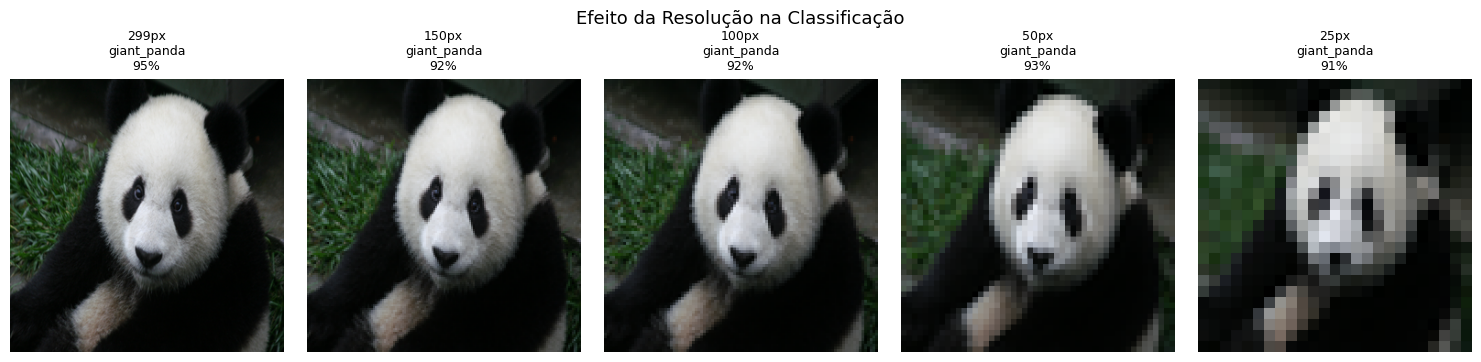

In [13]:
def test_different_sizes(image_path, sizes=[299, 150, 100, 50, 25]):
    """
    Testa o mesmo conteúdo em diferentes resoluções.
    Reduz a imagem e depois amplia para 299x299.
    """
    original = PILImage.open(image_path).convert('RGB')

    results = []

    for size in sizes:
        # Reduz para tamanho 'size' x 'size'
        small = original.resize((size, size), PILImage.LANCZOS)
        # Amplia de volta para 299x299
        large = small.resize((299, 299), PILImage.LANCZOS)

        # Processa
        arr = keras_image.img_to_array(large)
        arr = np.expand_dims(arr, 0)
        arr = preprocess_input(arr)

        preds = model.predict(arr, verbose=0)
        top1 = decode_predictions(preds, top=1)[0][0]

        results.append({
            'size': size,
            'label': top1[1],
            'score': top1[2]
        })
        print(f"  {size:3d}x{size:3d} px → {top1[1]:<25s} ({top1[2]*100:.1f}%)")

    # Visualiza
    fig, axes = plt.subplots(1, len(sizes), figsize=(3*len(sizes), 3.5))
    for ax, size, res in zip(axes, sizes, results):
        small = original.resize((size, size), PILImage.LANCZOS)
        large = small.resize((299, 299), PILImage.NEAREST)  # Sem suavização p/ mostrar pixelização
        ax.imshow(large)
        ax.set_title(f"{size}px\n{res['label']}\n{res['score']*100:.0f}%", fontsize=9)
        ax.axis('off')

    plt.suptitle("Efeito da Resolução na Classificação", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


if os.path.exists('images/panda.jpg'):
    print("Testando diferentes resoluções — Panda:")
    test_different_sizes('images/panda.jpg')
elif os.path.exists('images/elephant.jpg'):
    print("Testando diferentes resoluções — Elefante:")
    test_different_sizes('images/elephant.jpg')


## 13. Visualização das Ativações (Feature Maps)

Podemos usar um **modelo intermediário** para extrair as ativações de camadas internas do InceptionV3 e visualizar o que ele "vê" em cada camada:


Camada 'mixed0': (35, 35, 256)


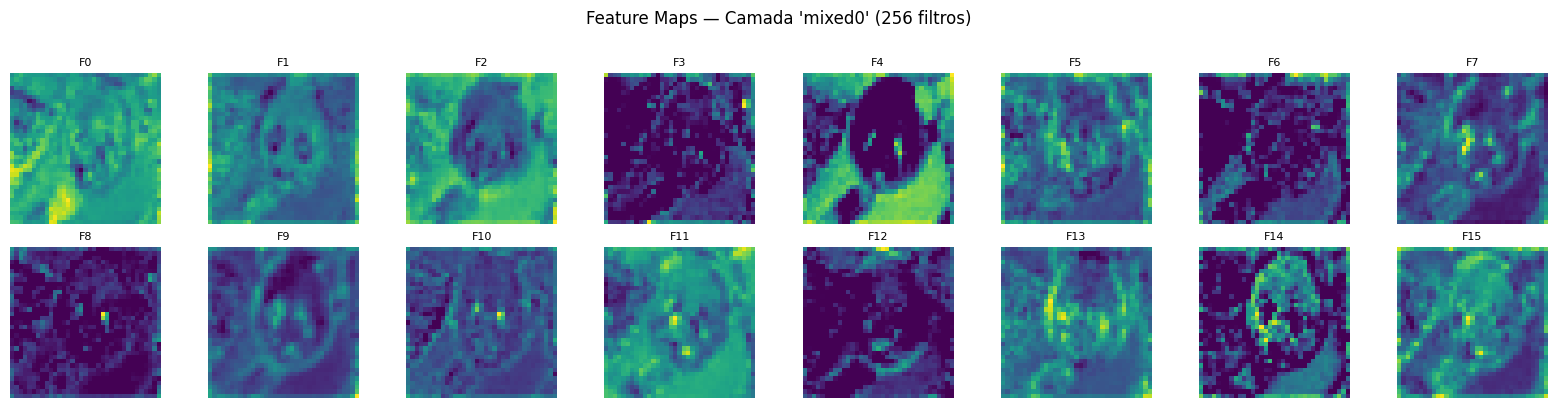

In [14]:
def visualize_feature_maps(image_path, layer_name='mixed0', n_features=16):
    """
    Extrai e visualiza os feature maps de uma camada intermediária.

    Parâmetros:
        layer_name: nome da camada para visualizar
            Algumas opções do InceptionV3:
            'mixed0', 'mixed1', 'mixed2',  # Módulos Inception iniciais
            'mixed3', 'mixed4', 'mixed5',  # Módulos do meio
            'mixed6', 'mixed7', 'mixed8',  # Módulos avançados
            'mixed9', 'mixed9_1'           # Módulos finais
        n_features: número de feature maps para exibir
    """
    # Modelo que retorna as ativações da camada especificada
    activation_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output
    )

    # Pré-processa a imagem
    img_array, _ = load_and_preprocess(image_path)

    # Obtém as ativações
    activations = activation_model.predict(img_array, verbose=0)[0]  # (H, W, C)

    print(f"Camada '{layer_name}': {activations.shape}")

    n_features = min(n_features, activations.shape[-1])
    cols = 8
    rows = (n_features + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

    for i in range(len(axes)):
        ax = axes[i] if hasattr(axes, '__len__') else axes
        if i < n_features:
            feature_map = activations[:, :, i]
            ax.imshow(feature_map, cmap='viridis')
            ax.set_title(f'F{i}', fontsize=8)
        ax.axis('off')

    plt.suptitle(f"Feature Maps — Camada '{layer_name}' ({activations.shape[-1]} filtros)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


# Visualiza feature maps de uma camada inicial
if os.path.exists('images/panda.jpg'):
    visualize_feature_maps('images/panda.jpg', layer_name='mixed0', n_features=16)


## 14. Listagem das Camadas Inception

Veja todas as camadas do modelo e seus formatos de saída:


In [15]:
# Lista as principais camadas (módulos Inception)
print(f"{'Camada':<40} {'Tipo':<25} {'Saída':<25}")
print("-" * 90)

for layer in model.layers:
    if 'mixed' in layer.name or 'predictions' in layer.name or 'input' in layer.name:
        try:
            out_shape = str(layer.output_shape)
        except AttributeError:
            out_shape = str(layer.output.shape)
        print(f"{layer.name:<40} {type(layer).__name__:<25} {out_shape:<25}")


Camada                                   Tipo                      Saída                    
------------------------------------------------------------------------------------------
input_layer                              InputLayer                (None, 299, 299, 3)      
mixed0                                   Concatenate               (None, 35, 35, 256)      
mixed1                                   Concatenate               (None, 35, 35, 288)      
mixed2                                   Concatenate               (None, 35, 35, 288)      
mixed3                                   Concatenate               (None, 17, 17, 768)      
mixed4                                   Concatenate               (None, 17, 17, 768)      
mixed5                                   Concatenate               (None, 17, 17, 768)      
mixed6                                   Concatenate               (None, 17, 17, 768)      
mixed7                                   Concatenate               (None

## 15. Transfer Learning — Configuração (Conceitual)

O InceptionV3 pode ser usado como **base para transfer learning** — reutilizamos as features aprendidas no ImageNet para uma nova tarefa com menos dados.

### Como funciona:
1. **Congela** as camadas do InceptionV3 (mantém os pesos treinados)
2. **Adiciona** novas camadas densas no topo para a nova tarefa
3. **Treina** apenas as novas camadas com seus dados


In [16]:
def create_transfer_model(num_classes, freeze_base=True):
    """
    Cria um modelo de transfer learning baseado no InceptionV3.

    Parâmetros:
        num_classes: número de classes do seu problema
        freeze_base: se True, congela os pesos do InceptionV3
    """
    # Base: InceptionV3 sem a camada de classificação final
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,      # Remove a camada Softmax do ImageNet
        input_shape=(299, 299, 3)
    )

    # Congela os pesos da base
    base_model.trainable = not freeze_base

    # Novas camadas para a nova tarefa
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)   # Reduz (H, W, C) → (C,)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    transfer_model = tf.keras.Model(inputs=base_model.input, outputs=output)

    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return transfer_model, base_model


# Exemplo: modelo para 5 classes (ex: cães, gatos, pássaros, carros, flores)
transfer_model, base_model = create_transfer_model(num_classes=5)

print("Modelo de Transfer Learning criado:")
print(f"  Camadas totais: {len(transfer_model.layers)}")
print(f"  Parâmetros treináveis: {sum([tf.size(v).numpy() for v in transfer_model.trainable_variables]):,}")
print(f"  Parâmetros não-treináveis: {sum([tf.size(v).numpy() for v in transfer_model.non_trainable_variables]):,}")
print("\nCamadas finais (novas):")
for layer in transfer_model.layers[-5:]:
    try:
        shape = str(layer.output_shape)
    except AttributeError:
        shape = str(layer.output.shape)
    print(f"  {layer.name}: {shape}")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Modelo de Transfer Learning criado:
  Camadas totais: 315
  Parâmetros treináveis: 1,051,653
  Parâmetros não-treináveis: 21,802,786

Camadas finais (novas):
  mixed10: (None, 8, 8, 2048)
  global_average_pooling2d: (None, 2048)
  dense: (None, 512)
  dropout: (None, 512)
  dense_1: (None, 5)


## 16. Comparação: InceptionV3 vs Outras Arquiteturas

O Keras oferece várias arquiteturas pré-treinadas. Aqui está uma comparação:


Arquitetura          Parâm.(M)    Top-1 Acc    Entrada      Ano
-----------------------------------------------------------------
EfficientNetB7       66.7         84.3         600×600      2019
InceptionResNetV2    55.9         80.3         299×299      2016
Xception             22.9         79.0         299×299      2016
InceptionV3          23.9         77.9         299×299      2015 ◄
EfficientNetB0       5.3          77.1         224×224      2019
ResNet50V2           25.6         76.0         224×224      2016
MobileNetV3Large     5.4          75.6         224×224      2019
ResNet50             25.6         74.9         224×224      2015
VGG16                138.4        71.3         224×224      2014

◄ = Arquitetura usada neste tutorial
Top-1 Acc = Acurácia no ImageNet validation set


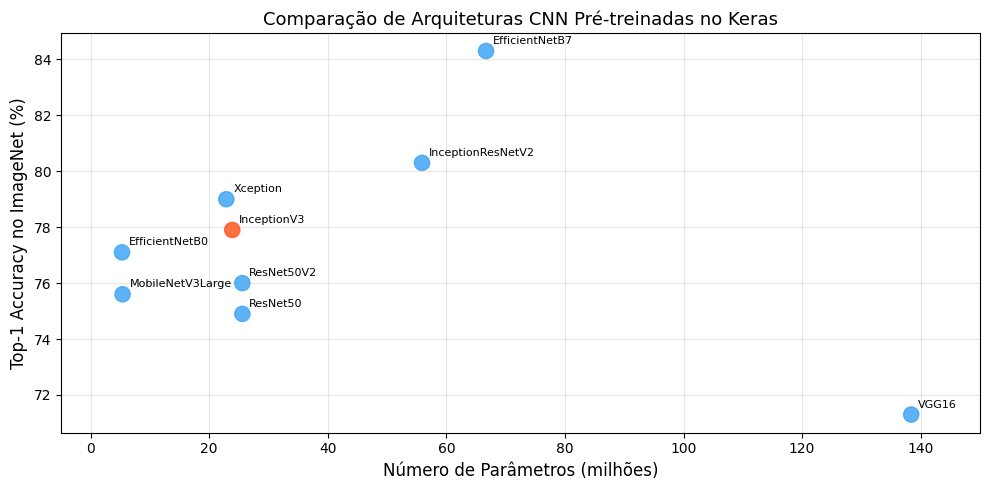

In [17]:
# Informações sobre arquiteturas disponíveis no Keras
architectures = [
    {"nome": "InceptionV3",       "params_M": 23.9, "top1_acc": 77.9, "input": "299×299", "ano": 2015},
    {"nome": "InceptionResNetV2", "params_M": 55.9, "top1_acc": 80.3, "input": "299×299", "ano": 2016},
    {"nome": "VGG16",             "params_M": 138.4, "top1_acc": 71.3, "input": "224×224", "ano": 2014},
    {"nome": "ResNet50",          "params_M": 25.6, "top1_acc": 74.9, "input": "224×224", "ano": 2015},
    {"nome": "ResNet50V2",        "params_M": 25.6, "top1_acc": 76.0, "input": "224×224", "ano": 2016},
    {"nome": "Xception",          "params_M": 22.9, "top1_acc": 79.0, "input": "299×299", "ano": 2016},
    {"nome": "EfficientNetB0",    "params_M": 5.3,  "top1_acc": 77.1, "input": "224×224", "ano": 2019},
    {"nome": "EfficientNetB7",    "params_M": 66.7, "top1_acc": 84.3, "input": "600×600", "ano": 2019},
    {"nome": "MobileNetV3Large",  "params_M": 5.4,  "top1_acc": 75.6, "input": "224×224", "ano": 2019},
]

print(f"{'Arquitetura':<20} {'Parâm.(M)':<12} {'Top-1 Acc':<12} {'Entrada':<12} {'Ano'}")
print("-" * 65)
for a in sorted(architectures, key=lambda x: x['top1_acc'], reverse=True):
    marker = " ◄" if a['nome'] == 'InceptionV3' else ""
    print(f"{a['nome']:<20} {a['params_M']:<12.1f} {a['top1_acc']:<12.1f} {a['input']:<12} {a['ano']}{marker}")

print("\n◄ = Arquitetura usada neste tutorial")
print("Top-1 Acc = Acurácia no ImageNet validation set")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
nomes = [a['nome'] for a in architectures]
params = [a['params_M'] for a in architectures]
accs = [a['top1_acc'] for a in architectures]
colors = ['#FF5722' if n == 'InceptionV3' else '#42A5F5' for n in nomes]

scatter = ax.scatter(params, accs, s=120, c=colors, alpha=0.85, zorder=3)
for nome, p, a in zip(nomes, params, accs):
    ax.annotate(nome, (p, a), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('Número de Parâmetros (milhões)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy no ImageNet (%)', fontsize=12)
ax.set_title('Comparação de Arquiteturas CNN Pré-treinadas no Keras', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 150)
plt.tight_layout()
plt.show()


## Conclusão

Neste tutorial, aprendemos a:

1. ✅ **Carregar** o InceptionV3 pré-treinado via `tf.keras.applications`
2. ✅ **Classificar imagens** com `decode_predictions`
3. ✅ **Visualizar feature maps** de camadas intermediárias
4. ✅ **Entender o impacto da resolução** na classificação
5. ✅ **Configurar Transfer Learning** para novas tarefas
6. ✅ **Comparar arquiteturas** disponíveis no Keras

### Diferenças em relação à versão original (TF1)

| Aspecto | TF1 (original) | TF2 (este notebook) |
|---------|---------------|---------------------|
| API | Sessões (`tf.Session`) | Eager execution (direto) |
| Modelo | `inception.py` customizado | `tf.keras.applications.InceptionV3` |
| Pré-processamento | Manual | `preprocess_input()` |
| Decodificação | Manual | `decode_predictions()` |
| Transfer Learning | Complexo | Simples com `.trainable` |

### Próximos Passos

- **Tutorial #10**: Fine-tuning do InceptionV3 para uma tarefa personalizada
- Experimente outras arquiteturas: `Xception`, `EfficientNet`, `ResNet`
- Explore **Grad-CAM** para visualizar onde o modelo "olha" na imagem


## Exercícios

1. **Teste suas próprias imagens** — use `classify('sua_imagem.jpg')` com fotos do seu computador. O modelo acerta?

2. **Compare resoluções** — pegue a mesma imagem em 25px, 50px, 100px e 299px. Em qual resolução o modelo começa a errar?

3. **Explore camadas** — use `visualize_feature_maps` com diferentes `layer_name` (ex: `'mixed0'`, `'mixed5'`, `'mixed9'`). O que muda entre camadas iniciais e finais?

4. **Transfer Learning** — crie um dataset pequeno (ex: 50 imagens de 2 categorias) e treine o modelo de transfer learning. Quantas épocas são necessárias para boa acurácia?

5. **Compare modelos** — substitua `InceptionV3` por `Xception` ou `EfficientNetB0`. O resultado muda para a mesma imagem?


## Licença (MIT)

Copyright (c) 2016 por [Magnus Erik Hvass Pedersen](http://www.hvass-labs.org/)  
Atualização para TF2, 2024.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software.
